## Data Exploration and Preprocessing

In [19]:
# --- 1. Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# --- 2. Load Data ---
print("Loading data...")
try:
    train_df = pd.read_csv('../data/train.csv')
    test_df = pd.read_csv('../data/test.csv') # Load test set if needed for final test
    print("Data loaded successfully.")
    print(f"Training data shape: {train_df.shape}")
    
    # Keep track of the test IDs if we use test_df later
    test_ids = test_df['Id'] if 'Id' in test_df.columns else None
except FileNotFoundError as e:
    print(f"Error loading data: {e}")
    print("Please ensure train.csv and test.csv are in the 'data/' directory.")
    # Stop execution if data isn't loaded (or handle differently)
    raise

Loading data...
Data loaded successfully.
Training data shape: (1460, 81)


In [5]:
print(train_df.shape)

(1460, 81)


In [15]:
# --- 3. Exploratory Data Analysis (EDA) ---
print("\n--- Starting EDA ---")


--- Starting EDA ---


In [16]:
# --- 3.1 Initial Inspection ---
print("\nTraining Data Info:")
train_df.info()


Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

In [17]:
print("\nTraining Data Description (Numerical Features):")
# Use .describe(include='all') to include stats for object types too
print(train_df.describe())


Training Data Description (Numerical Features):
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.2

In [18]:
print("\nFirst 5 Rows (Head):")
print(train_df.head())


First 5 Rows (Head):
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  


Analyzing Target Variable: SalePrice


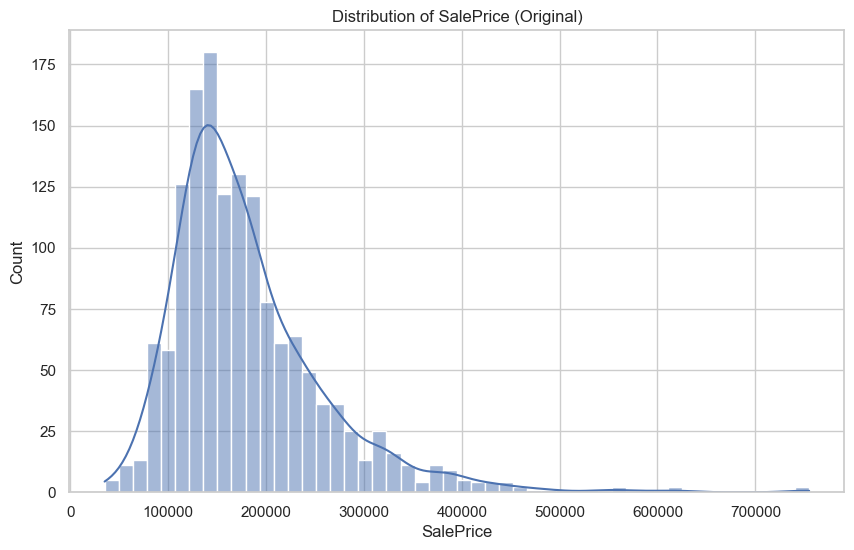

In [20]:
# --- 3.2 Target Variable Analysis (SalePrice) ---
print("\nAnalyzing Target Variable: SalePrice")
plt.figure(figsize=(10, 6))
sns.histplot(train_df['SalePrice'], kde=True, bins=50)
plt.title('Distribution of SalePrice (Original)')
plt.show()

In [21]:
# Observation: SalePrice is right-skewed. Log transformation is common for this.
# We apply log1p which calculates log(1 + x) - handles potential zeros
train_df['SalePriceLog'] = np.log1p(train_df['SalePrice'])

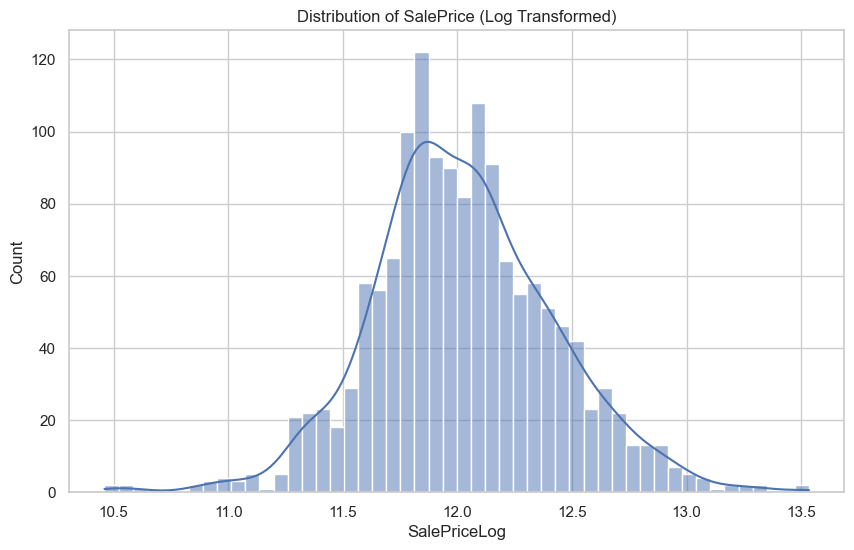

SalePrice seems right-skewed. Log transformation (SalePriceLog) applied for potentially better modeling.


In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(train_df['SalePriceLog'], kde=True, bins=50)
plt.title('Distribution of SalePrice (Log Transformed)')
plt.show()
print("SalePrice seems right-skewed. Log transformation (SalePriceLog) applied for potentially better modeling.")

In [26]:
# --- 3.3 Missing Value Analysis ---
print("\nAnalyzing Missing Values...")
missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0] # Filter only columns with missing values
print(missing_values.sort_values(inplace=True, ascending=False))


Analyzing Missing Values...
None


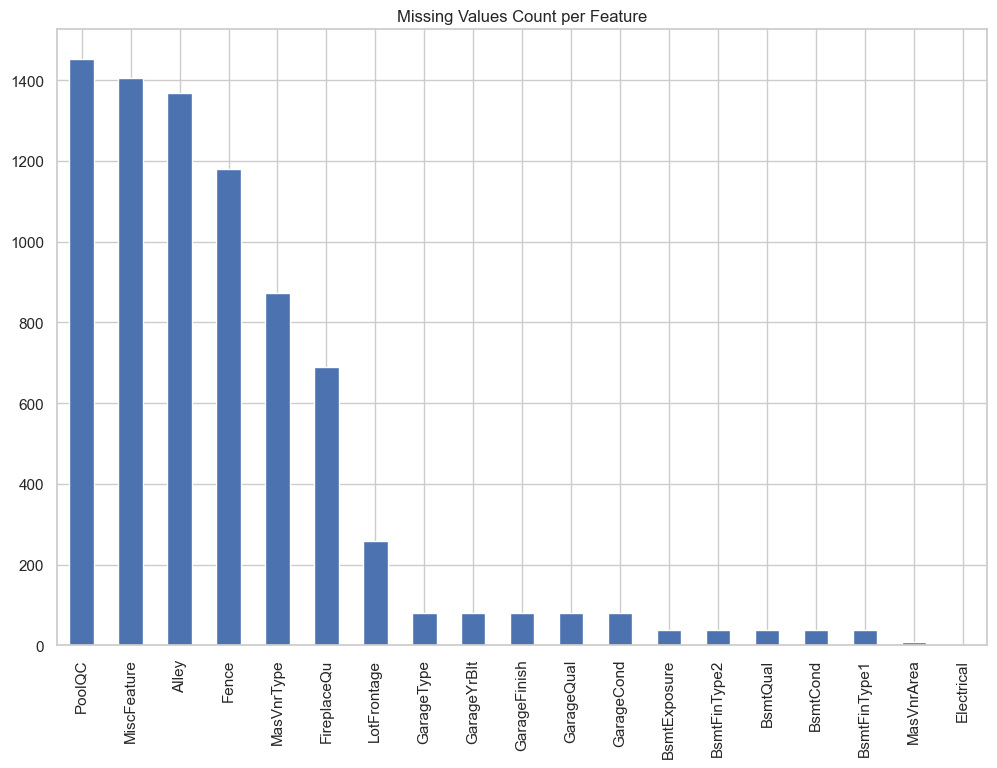

In [27]:
plt.figure(figsize=(12, 8))
missing_values.plot.bar()
plt.title('Missing Values Count per Feature')
plt.show()

In [29]:
print("\nColumns with Missing Values (Sorted):")
print(missing_values)
# Note: We will handle these in the preprocessing step. Common strategies:
# - Numerical: Impute with median (robust to outliers) or mean.
# - Categorical: Impute with mode (most frequent) or a constant like 'None'.
# - Drop features if too many values are missing (e.g., > 50-70%) and they don't seem crucial.
# - Drop rows if only a tiny fraction have missing values (less common).


Columns with Missing Values (Sorted):
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [31]:
# --- 3.4 Correlation Analysis ---
print("\nAnalyzing Correlations...")

# Select only numerical features for standard correlation matrix
numerical_features = train_df.select_dtypes(include=np.number)

# Calculate correlation with the log-transformed target variable
log_target_corr = numerical_features.corr()['SalePriceLog'].sort_values(ascending=False)

print("\nTop 15 Features Correlated with SalePriceLog:")
print(log_target_corr.head(15))

print("\nBottom 15 Features Correlated with SalePriceLog:")
print(log_target_corr.tail(15))


Analyzing Correlations...

Top 15 Features Correlated with SalePriceLog:
SalePriceLog    1.000000
SalePrice       0.948374
OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
GarageYrBlt     0.541073
TotRmsAbvGrd    0.534422
Fireplaces      0.489450
MasVnrArea      0.430809
Name: SalePriceLog, dtype: float64

Bottom 15 Features Correlated with SalePriceLog:
BedroomAbvGr     0.209043
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057330
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
Id              -0.017942
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorch   -0.149050
Name: SalePriceLog, dtype: float64


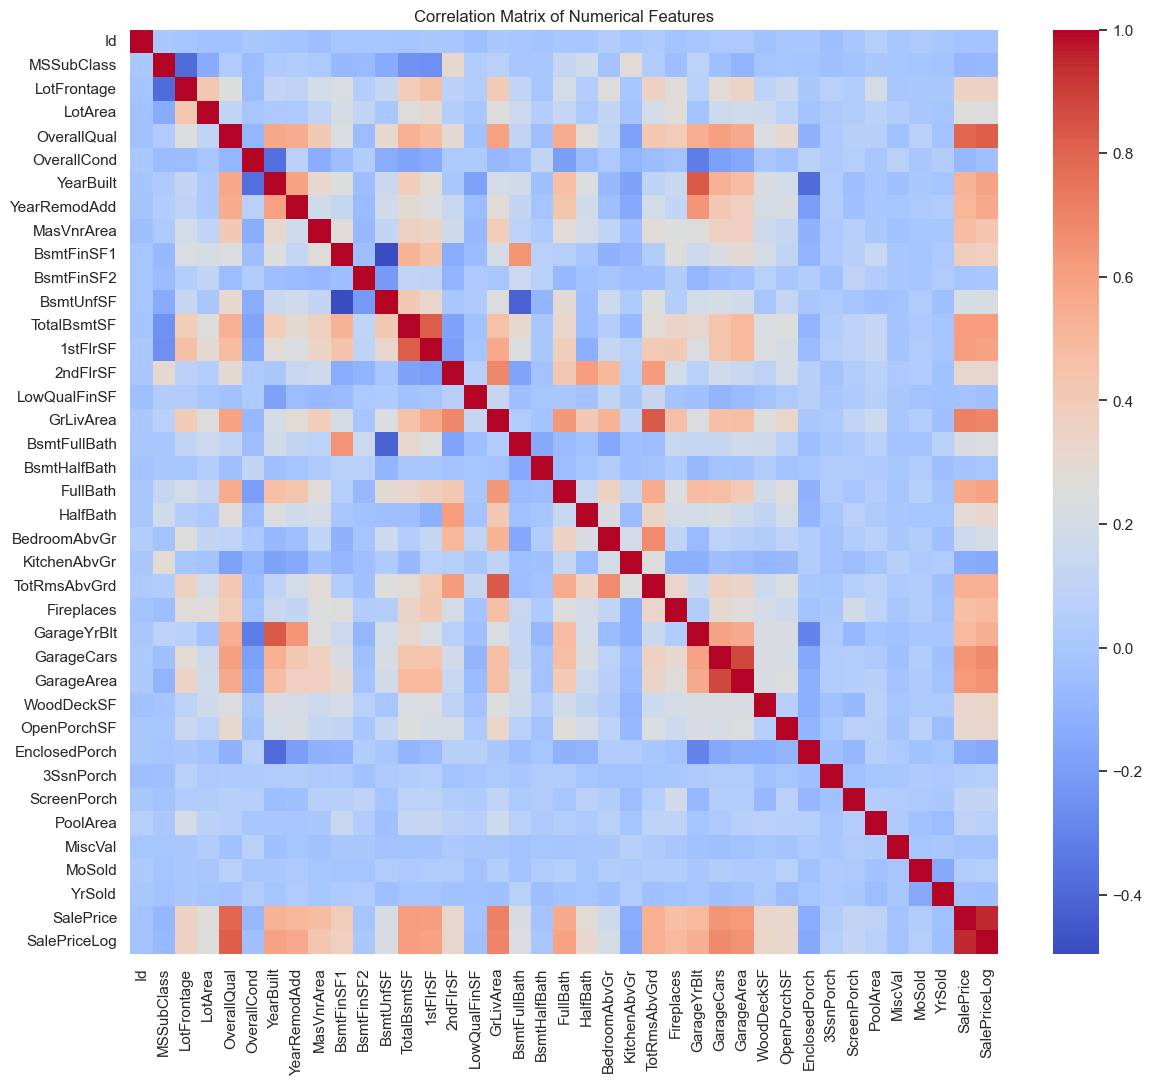

In [32]:
# Visualize overall correlation matrix (can be dense)
plt.figure(figsize=(14, 12))
correlation_matrix = numerical_features.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f") # Add annot=True for values if matrix isn't too big
plt.title('Correlation Matrix of Numerical Features')
plt.show()


Checking for Outliers (Example: GrLivArea vs SalePriceLog)


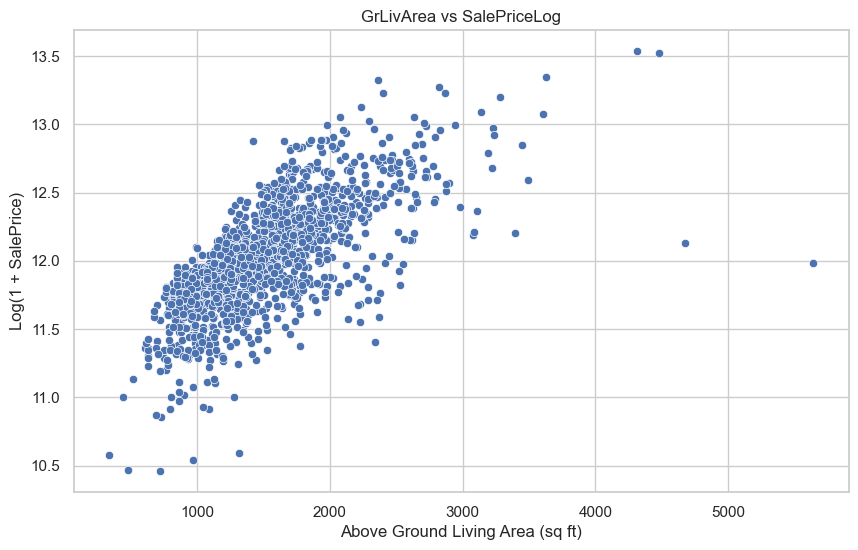

In [34]:
# --- 3.5 Outlier Exploration (Example: GrLivArea) ---
# Features highly correlated with SalePrice are good candidates to check for outliers

print("\nChecking for Outliers (Example: GrLivArea vs SalePriceLog)")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df['GrLivArea'], y=train_df['SalePriceLog'])

plt.title('GrLivArea vs SalePriceLog')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Log(1 + SalePrice)')
plt.show()
# Observation: There might be a couple of points with very large GrLivArea but low SalePriceLog.
# These could be outliers affecting a linear model. We might consider removing them later.
# General strategy: Boxplots for numerical features, scatter plots vs target for key features.


Exploring Categorical Features (Example: OverallQual vs SalePriceLog)


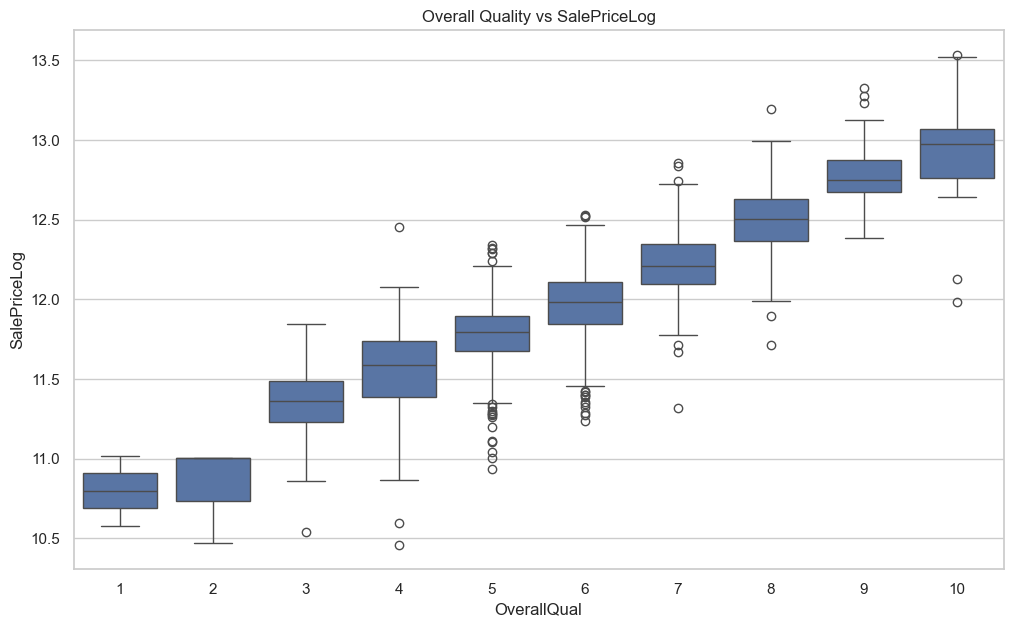

--- EDA Finished ---


In [35]:
# --- 3.6 Categorical Feature Exploration (Example: OverallQual) ---
print("\nExploring Categorical Features (Example: OverallQual vs SalePriceLog)")

plt.figure(figsize=(12, 7))
sns.boxplot(x=train_df['OverallQual'], y=train_df['SalePriceLog'])

plt.title('Overall Quality vs SalePriceLog')
plt.show()
# Observation: Clear positive relationship. Higher quality means higher price. Boxplots are good for comparing distributions across categories.

print("--- EDA Finished ---")

## Data Cleaning & Feature Engineering

In [38]:
# --- 4. Data Cleaning & Feature Engineering ---
print("\n--- Starting Cleaning & Feature Engineering ---")


--- Starting Cleaning & Feature Engineering ---


In [37]:
# We'll modify train_df directly for simplicity here.
# In practice, you might create functions or use pipelines, especially if applying to test_df too.

In [39]:
# --- 4.1 Handle Potential Outliers (Identified in EDA) ---
# Example: Removing the two points with GrLivArea > 4000 and low SalePriceLog

outlier_indices = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePriceLog'] < 12)].index
if not outlier_indices.empty:
    print(f"\nRemoving {len(outlier_indices)} potential outliers based on GrLivArea and SalePriceLog.")
    train_df = train_df.drop(outlier_indices)
    print(f"New training shape after outlier removal: {train_df.shape}")


Removing 1 potential outliers based on GrLivArea and SalePriceLog.
New training shape after outlier removal: (1459, 82)


In [41]:
# --- 4.2 Handle Missing Values ---
print("\nHandling Missing Values...")


Handling Missing Values...


In [43]:
# Strategy: Impute based on feature type and meaning (refer to data_description.txt from Kaggle)

In [49]:
# Example Imputations (adjust based on detailed analysis):

# PoolQC: NaN likely means 'No Pool'. Fill with 'None'.
train_df['PoolQC'] = train_df['PoolQC'].fillna('None')

# MiscFeature: NaN means 'No Misc Feature'.
train_df['MiscFeature'] = train_df['MiscFeature'].fillna('None')

# Alley: NaN means 'No alley access'.
train_df['Alley'] = train_df['Alley'].fillna('None')

# Fence: NaN means 'No Fence'.
train_df['Fence'] = train_df['Fence'].fillna('None')

# FireplaceQu: NaN means 'No Fireplace'.
train_df['FireplaceQu'] = train_df['FireplaceQu'].fillna('None')

# LotFrontage: Numerical. Could be related to neighborhood. Impute with median of the neighborhood.
train_df['LotFrontage'] = train_df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# Garage Features (Categorical): NaN means 'No Garage'.
for col in ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']:
    train_df[col] = train_df[col].fillna('None')

# Garage Features (Numerical): NaN means 'No Garage', so 0 is appropriate.
for col in ['GarageYrBlt', 'GarageArea', 'GarageCars']: train_df[col] = train_df[col].fillna(0)

# Basement Features (Categorical): NaN means 'No Basement'.
for col in ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']:
    train_df[col] = train_df[col].fillna('None')
    
# Basement Features (Numerical): NaN means 'No Basement', so 0.
for col in ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']:
    train_df[col] = train_df[col].fillna(0)
    
# MasVnrType: Categorical. 'None' is likely for NaN.
train_df['MasVnrType'] = train_df['MasVnrType'].fillna('None')

# MasVnrArea: Numerical. 0 if MasVnrType is 'None'.
train_df['MasVnrArea'] = train_df['MasVnrArea'].fillna(0)

# Electrical: Only 1 missing value. Impute with the mode.
train_df['Electrical'] = train_df['Electrical'].fillna(train_df['Electrical'].mode()[0])

In [50]:
# Verify no missing values remain (or handle any stragglers)
print("\nMissing values remaining after imputation:")
print(train_df.isnull().sum().sum()) # Should ideally be 0


Missing values remaining after imputation:
0


In [52]:
# --- 4.3 Feature Engineering ---
print("\nPerforming Feature Engineering...")


Performing Feature Engineering...


In [53]:
# Combine square footage features
train_df['TotalSF'] = train_df['TotalBsmtSF'] + train_df['1stFlrSF'] + train_df['2ndFlrSF']

# Simplify quality features (example: combine overall and external) - Requires careful thought!
# train_df['OverallGrade'] = train_df['OverallQual'] * train_df['OverallCond']

# Age related features
train_df['HouseAge'] = train_df['YrSold'] - train_df['YearBuilt']
train_df['RemodAge'] = train_df['YrSold'] - train_df['YearRemodAdd']
train_df['IsRemodeled'] = (train_df['YearRemodAdd'] != train_df['YearBuilt']).astype(int)
# You can create many more features: Total Bathrooms, Porch Area, etc.

In [54]:
# --- 4.4 Skewed Numerical Features ---

# Some numerical features might also be skewed. Log transform them.
# First, identify numerical features (excluding Id and target)

numerical_cols = train_df.select_dtypes(include=np.number).columns
numerical_cols = numerical_cols.drop(['Id', 'SalePrice', 'SalePriceLog']) # Exclude Id and targets

In [55]:
# Calculate skewness
skewness = train_df[numerical_cols].apply(lambda x: x.skew()).sort_values(ascending=False)

# Define a threshold for skewness
skew_threshold = 0.75
highly_skewed_cols = skewness[abs(skewness) > skew_threshold].index

print(f"\nApplying log1p transformation to {len(highly_skewed_cols)} highly skewed numerical features.")
for col in highly_skewed_cols:
    train_df[col] = np.log1p(train_df[col])


Applying log1p transformation to 22 highly skewed numerical features.


In [56]:
# --- 4.5 Encode Categorical Features ---
print("\nEncoding Categorical Features using One-Hot Encoding...")

# Drop original SalePrice and Id before encoding/modeling
train_df_processed = train_df.drop(['Id', 'SalePrice'], axis=1)

# Apply one-hot encoding
train_df_processed = pd.get_dummies(train_df_processed)

print(f"Shape after one-hot encoding: {train_df_processed.shape}")


Encoding Categorical Features using One-Hot Encoding...
Shape after one-hot encoding: (1459, 306)


In [57]:
# Store the target variable separately (log-transformed)
y = train_df_processed['SalePriceLog']

# Drop the target from the features
X = train_df_processed.drop('SalePriceLog', axis=1)

In [58]:
# **Important:** Save the columns from X NOW.
# This ensures that when you process new data (like test data or app input),
# it will have the exact same columns in the same order.

feature_columns = X.columns.tolist()

print("--- Cleaning & Feature Engineering Finished ---")

--- Cleaning & Feature Engineering Finished ---


## Model Building, Evaluation, and Saving
Goal: Train models, evaluate them, and save the best one along with necessary components (scaler, columns).

In [59]:
# --- 5. Model Building ---

print("\n--- Starting Model Building ---")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler # RobustScaler is less sensitive to outliers
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
import pickle


--- Starting Model Building ---


In [60]:
# --- 5.1 Split Data (Train/Validation) ---

# We already have X and y prepared from the previous step

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
# X_valid = X_test

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_valid.shape}")

Training set shape: (1167, 305)
Validation set shape: (292, 305)


In [61]:
# --- 5.2 Feature Scaling ---

# Use RobustScaler if outliers might still be influential, otherwise StandardScaler
scaler = RobustScaler() # Or StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid) # Use transform only on validation/test set

print("Features scaled.")

Features scaled.


In [62]:
# --- 5.3 Model Training ---

print("\nTraining models...")

# Define models
lr = LinearRegression()
# Alpha values for Ridge/Lasso often need tuning (see Optimization section)

ridge = Ridge(alpha=10.0) # Example alpha

lasso = Lasso(alpha=0.001) # Example alpha

# Train models
lr.fit(X_train_scaled, y_train)
print("Linear Regression trained.")

ridge.fit(X_train_scaled, y_train)
print("Ridge Regression trained.")

lasso.fit(X_train_scaled, y_train)
print("Lasso Regression trained.")


Training models...
Linear Regression trained.
Ridge Regression trained.
Lasso Regression trained.


In [64]:
# --- 5.4 Model Evaluation ---

print("\nEvaluating models on validation set...")

def rmse(y_true, y_pred):
    # Remember y is log-transformed, so RMSE is on log scale
    return np.sqrt(mean_squared_error(y_true, y_pred))

lr_preds = lr.predict(X_valid_scaled)
ridge_preds = ridge.predict(X_valid_scaled)
lasso_preds = lasso.predict(X_valid_scaled)

lr_rmse = rmse(y_valid, lr_preds)
ridge_rmse = rmse(y_valid, ridge_preds)
lasso_rmse = rmse(y_valid, lasso_preds)

print(f"Linear Regression Log-RMSE: {lr_rmse:.5f}")
print(f"Ridge Regression Log-RMSE: {ridge_rmse:.5f}")
print(f"Lasso Regression Log-RMSE: {lasso_rmse:.5f}")

# Interpretation: Lower Log-RMSE is better. This score is useful for comparing models.
# For showing actual price error, you'd exponentiate predictions:
# final_preds = np.expm1(ridge.predict(X_test_scaled)) # if using test set


Evaluating models on validation set...
Linear Regression Log-RMSE: 0.33377
Ridge Regression Log-RMSE: 0.11929
Lasso Regression Log-RMSE: 0.11913


In [65]:
# --- 5.5 Cross-Validation (More Robust Evaluation) ---

print("\nPerforming 5-Fold Cross-Validation (Example with Ridge)...")

# Use the chosen model (e.g., Ridge which often performs well here)
# CV is done on the *entire* training set (X, y) before the final split, or on X_train/y_train
# Let's do it on the full X before the final split for a better overall estimate
# Need to scale within the CV pipeline to prevent data leakage

from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(RobustScaler(), Ridge(alpha=10.0))
cv_scores = cross_val_score(pipeline, X, y, # Use full dataset X, y before split
                            scoring='neg_mean_squared_error', cv=5)


Performing 5-Fold Cross-Validation (Example with Ridge)...


In [66]:
# Scores are negative MSE, so take sqrt of negative scores
cv_rmse_scores = np.sqrt(-cv_scores)

print(f"Cross-Validation RMSE scores: {cv_rmse_scores}")
print(f"Average CV RMSE: {cv_rmse_scores.mean():.5f} (+/- {cv_rmse_scores.std():.5f})")

Cross-Validation RMSE scores: [0.10693018 0.1384403  0.12287671 0.10496621 0.11447424]
Average CV RMSE: 0.11754 (+/- 0.01221)


In [69]:
# --- 5.6 Save the Best Model, Scaler, and Columns ---

print("\nSaving model artifacts...")

import os # <<< Add this import

# Choose the best model based on validation/CV (let's assume Ridge)
best_model = ridge
model_path = '../models/house_price_model.pkl'
scaler_path = '../models/scaler.pkl' # Need to save the scaler too!
columns_path = '../models/feature_columns.pkl'

# --- >>> Create the models directory if it doesn't exist <<< ---
models_dir = os.path.dirname(model_path) # Gets '../models'
os.makedirs(models_dir, exist_ok=True) # Creates the directory, doesn't error if it already exists
print(f"Ensured directory exists: {models_dir}")
# --- >>> <<< ---


Saving model artifacts...
Ensured directory exists: ../models


In [70]:
# Save the trained model object

try:
    with open(model_path, 'wb') as f:
        pickle.dump(best_model, f)
    print(f"Model saved to {model_path}")
except Exception as e:
    print(f"Error saving model: {e}")

Model saved to ../models/house_price_model.pkl


In [71]:
# Save the fitted scaler object

# Refit scaler on the *entire* training data (X) before saving if using for prediction on new data
scaler_final = RobustScaler()
scaler_final.fit(X) # Fit on all training data X

try:
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler_final, f)
    print(f"Scaler saved to {scaler_path}")
except Exception as e:
    print(f"Error saving scaler: {e}")

Scaler saved to ../models/scaler.pkl


In [72]:
# Save the list of feature columns
try:
    with open(columns_path, 'wb') as f:
        pickle.dump(feature_columns, f)
    print(f"Feature columns saved to {columns_path}")
except Exception as e:
    print(f"Error saving feature columns: {e}")


print("--- Model Building Finished ---")

Feature columns saved to ../models/feature_columns.pkl
--- Model Building Finished ---


## Streamlit App
Goal: Create a web interface to use the saved model for predictions.

## Optimization Strategies
Goal: Improve the model's predictive performance (lower RMSE).

1. More Feature Engineering: This often yields the biggest gains.

    - Interactions: Combine features (e.g., OverallQual * GrLivArea).
    - Polynomial Features: Create squared or cubed versions of important numerical features (sklearn.preprocessing.PolynomialFeatures).
    - Better Categorical Handling: Instead of pure one-hot encoding for high-cardinality features (like Neighborhood), explore Target Encoding or Frequency Encoding (be cautious of data leakage with target encoding – apply it within cross-validation folds).
    - Domain Knowledge: Read about factors affecting house prices in Ames, Iowa. Are there features related to location quality, schools, etc., that can be better captured?

2. Advanced Missing Value Imputation:

    - Use sklearn.impute.KNNImputer (imputes based on nearest neighbors).
    - Use sklearn.impute.IterativeImputer (models each feature with missing values as a function of other features).

3. Outlier Treatment: Instead of just removing, consider capping values at a certain percentile (winsorizing) or using models less sensitive to outliers (like RobustScaler or tree-based models).

4. Better Models:

    - Gradient Boosting: XGBoost (xgboost), LightGBM (lightgbm), CatBoost (catboost) are often top performers for tabular data. They build trees sequentially, correcting errors from previous trees.
    - Random Forests: (sklearn.ensemble.RandomForestRegressor) Builds many decision trees independently and averages their predictions. Generally robust.
    - Ensembling/Stacking: Combine predictions from multiple diverse models (e.g., averaging Ridge, XGBoost, LightGBM predictions). sklearn.ensemble.StackingRegressor or VotingRegressor.

5. Hyperparameter Tuning: Models have settings (hyperparameters) that aren't learned from data directly (e.g., alpha in Ridge/Lasso, n_estimators or max_depth in tree models). Find the best settings using:

    - sklearn.model_selection.GridSearchCV: Tries every combination of parameters you specify. Can be slow.
    - sklearn.model_selection.RandomizedSearchCV: Tries random combinations, often more efficient.
    - Important: Perform tuning using cross-validation to get reliable estimates of performance for each parameter set.

6. Cross-Validation: Use cross_val_score or manual k-fold loops during model selection and tuning for a more robust evaluation than a single train-validation split. Train the final chosen model (with best hyperparameters) on the entire training dataset (X, y) before saving.

7. Feature Selection: If you have too many features (especially after one-hot encoding), explicitly select the most important ones using:

    - Lasso regularization (it shrinks irrelevant feature coefficients to zero).
    - Feature importance from tree-based models (XGBoost, RandomForest).
    - Recursive Feature Elimination (sklearn.feature_selection.RFE).

Remember to apply optimizations iteratively and evaluate their impact carefully using your validation set or cross-validation. Good luck!